In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Histogram of Genome Counts per Bin

In [2]:
binary = pd.read_csv('AllBiomesBinaryFinal.txt', delimiter = '\t', index_col= 0) #this is every genome, EC, and the biome it is in. Cresten Concatanated each dataframe. 
# binary.columns 
binary.head()


,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16,Biome
Name_of_Genome,,,,,,,,,,,,,,,,,,,,,
3300056625_228,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300056625_197,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,ActivatedSludge
3300055001_136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ActivatedSludge
3300055001_94,1,1,1,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,ActivatedSludge
3300056626_306,0,1,1,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,ActivatedSludge


In [3]:
binary.index #index is our genomes
binary['Biome'] = binary['Biome'].astype('category')
# binary.dtypes


In [4]:
sums = binary.loc[ :, binary.columns != 'Biome']
sums = sums.sum()
sums

1_1_1_1     3586
1_1_1_2     1557
1_1_1_3     4531
1_1_1_4      483
1_1_1_5        0
            ... 
7_6_2_12     138
7_6_2_13     734
7_6_2_14    1956
7_6_2_15     201
7_6_2_16     612
Length: 8269, dtype: int64

In [5]:
counts = binary['Biome'].value_counts()
counts = pd.DataFrame(counts)
counts = counts.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
counts = counts.rename(columns={'count': 'Total Genomes'})
counts = counts.reset_index()
counts

,Biome,Total Genomes
0,Bulk Soil,2267
1,Lake Sediment,2186
2,Activated Sludge,1374
3,Cow Rumen,1293
4,River Sediment,633


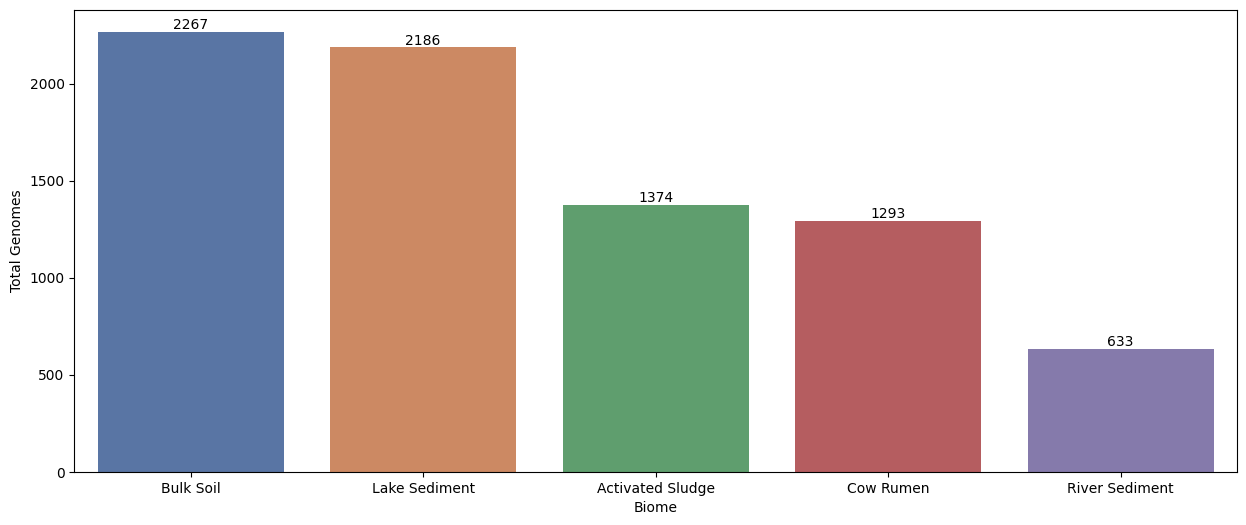

In [6]:
plt.figure(figsize=(15,6))
ax = sns.barplot(x='Biome', y='Total Genomes', data = counts, palette = 'deep')
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

In [7]:
column_sums = binary.groupby(by='Biome', observed=False).sum()
ec_sums = pd.DataFrame(column_sums)
clean = ec_sums.rename(index={'ActivatedSludge': 'Activated Sludge', 'BulkSoil': 'Bulk Soil', 'LakeSediment': 'Lake Sediment', 'CowRumen':'Cow Rumen', 'RiverSediment':'River Sediment'})
# for col in clean.columns:
#     if clean[col].sum()<=100:
#         del clean[col]
# print(ec_sums)
clean

# test = clean.loc['Activated Sludge'].sum()
# test

,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_7,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16
Biome,,,,,,,,,,,,,,,,,,,,,
Activated Sludge,411,373,751,46,0,43,0,1,86,86,...,135,171,92,306,552,57,86,270,33,130
Bulk Soil,1726,416,1564,273,0,85,0,0,271,191,...,617,367,499,775,1487,41,397,803,86,263
Cow Rumen,273,64,607,20,0,112,0,1,37,5,...,45,131,90,109,702,8,39,257,13,26
Lake Sediment,840,504,1208,84,0,114,0,0,156,25,...,175,265,145,254,822,9,168,478,42,111
River Sediment,336,200,401,60,0,28,0,0,45,25,...,84,75,107,127,349,23,44,148,27,82


In [8]:
clean.loc['Activated Sludge'] = (clean.loc['Activated Sludge'] / 1374) 
clean.loc['Bulk Soil'] = (clean.loc['Bulk Soil'] / 2267) 
clean.loc['Cow Rumen'] = (clean.loc['Cow Rumen'] / 1293) 
clean.loc['Lake Sediment'] = (clean.loc['Lake Sediment'] / 2186) 
clean.loc['River Sediment'] = (clean.loc['River Sediment'] / 633) 
clean

,1_1_1_1,1_1_1_2,1_1_1_3,1_1_1_4,1_1_1_5,1_1_1_6,1_1_1_7,1_1_1_8,1_1_1_9,1_1_1_10,...,7_6_2_7,7_6_2_8,7_6_2_9,7_6_2_10,7_6_2_11,7_6_2_12,7_6_2_13,7_6_2_14,7_6_2_15,7_6_2_16
Biome,,,,,,,,,,,,,,,,,,,,,
Activated Sludge,0.299127,0.271470,0.546579,0.033479,0,0.031295,0,0.000728,0.062591,0.062591,...,0.098253,0.124454,0.066958,0.222707,0.401747,0.041485,0.062591,0.196507,0.024017,0.094614
Bulk Soil,0.761359,0.183502,0.689899,0.120423,0,0.037494,0,0.000000,0.119541,0.084252,...,0.272166,0.161888,0.220115,0.341861,0.655933,0.018086,0.175121,0.354213,0.037936,0.116012
Cow Rumen,0.211137,0.049497,0.469451,0.015468,0,0.086620,0,0.000773,0.028616,0.003867,...,0.034803,0.101315,0.069606,0.084300,0.542923,0.006187,0.030162,0.198763,0.010054,0.020108
Lake Sediment,0.384263,0.230558,0.552608,0.038426,0,0.052150,0,0.000000,0.071363,0.011436,...,0.080055,0.121226,0.066331,0.116194,0.376029,0.004117,0.076853,0.218664,0.019213,0.050778
River Sediment,0.530806,0.315956,0.633491,0.094787,0,0.044234,0,0.000000,0.071090,0.039494,...,0.132701,0.118483,0.169036,0.200632,0.551343,0.036335,0.069510,0.233807,0.042654,0.129542


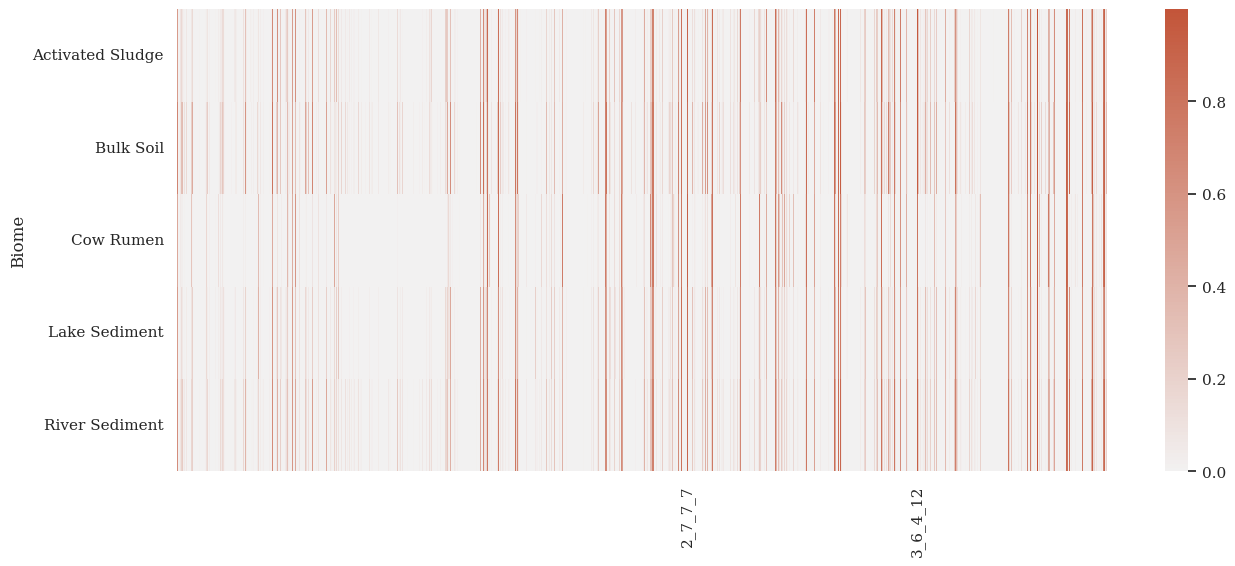

In [9]:
sns.set_context(context = 'paper')
sns.set_theme(font='serif')
plt.figure(figsize=(15,6))
color = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(data=clean, alpha = 1, center=0, cmap=color)
ticks = plt.gca().get_xticks()
selected_labels = ['2_7_7_7', '3_6_4_12']
selected_xticks = [i for i, label in enumerate(clean.columns) if label in selected_labels]
plt.xticks(ticks=selected_xticks, labels = selected_labels)
plt.show()

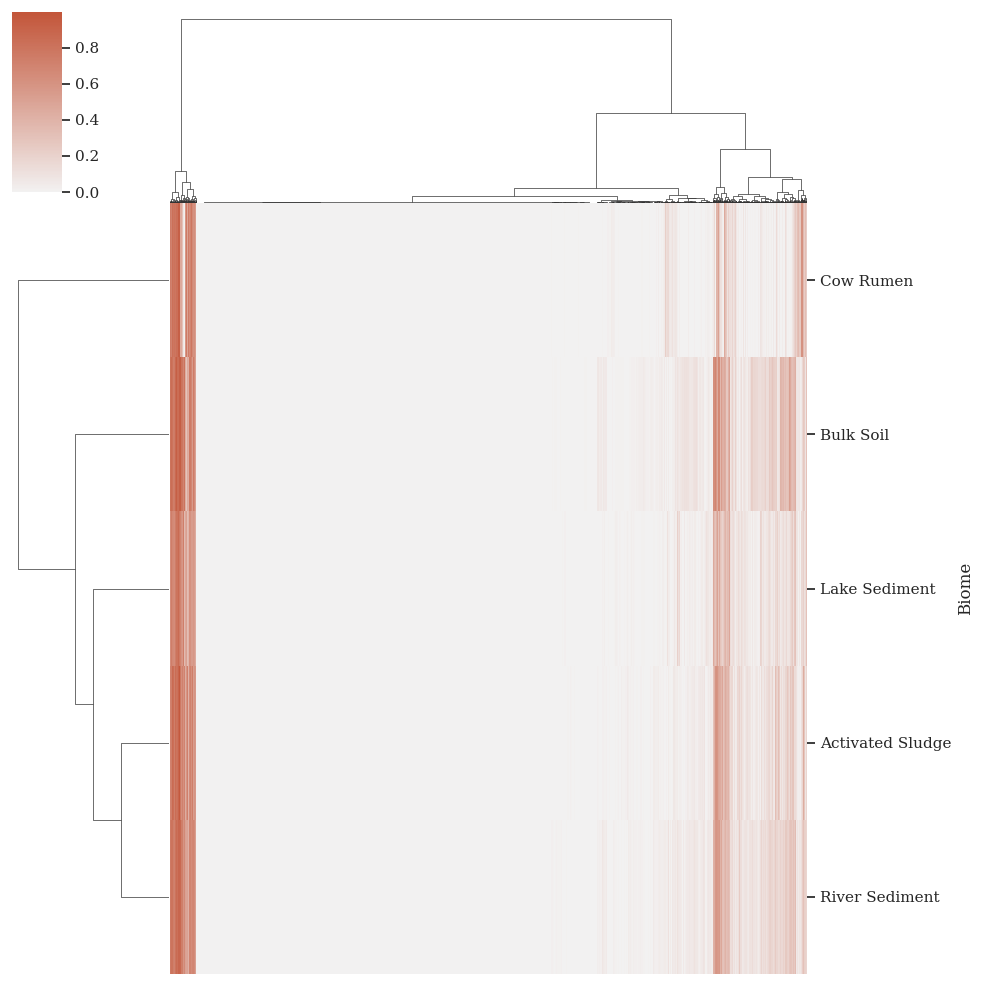

In [10]:
sns.set_context(context = 'paper')
sns.set_theme(font='serif')
sns.clustermap(clean, method = 'ward', metric='euclidean', cmap = color, center = 0, xticklabels = False)
plt.show()

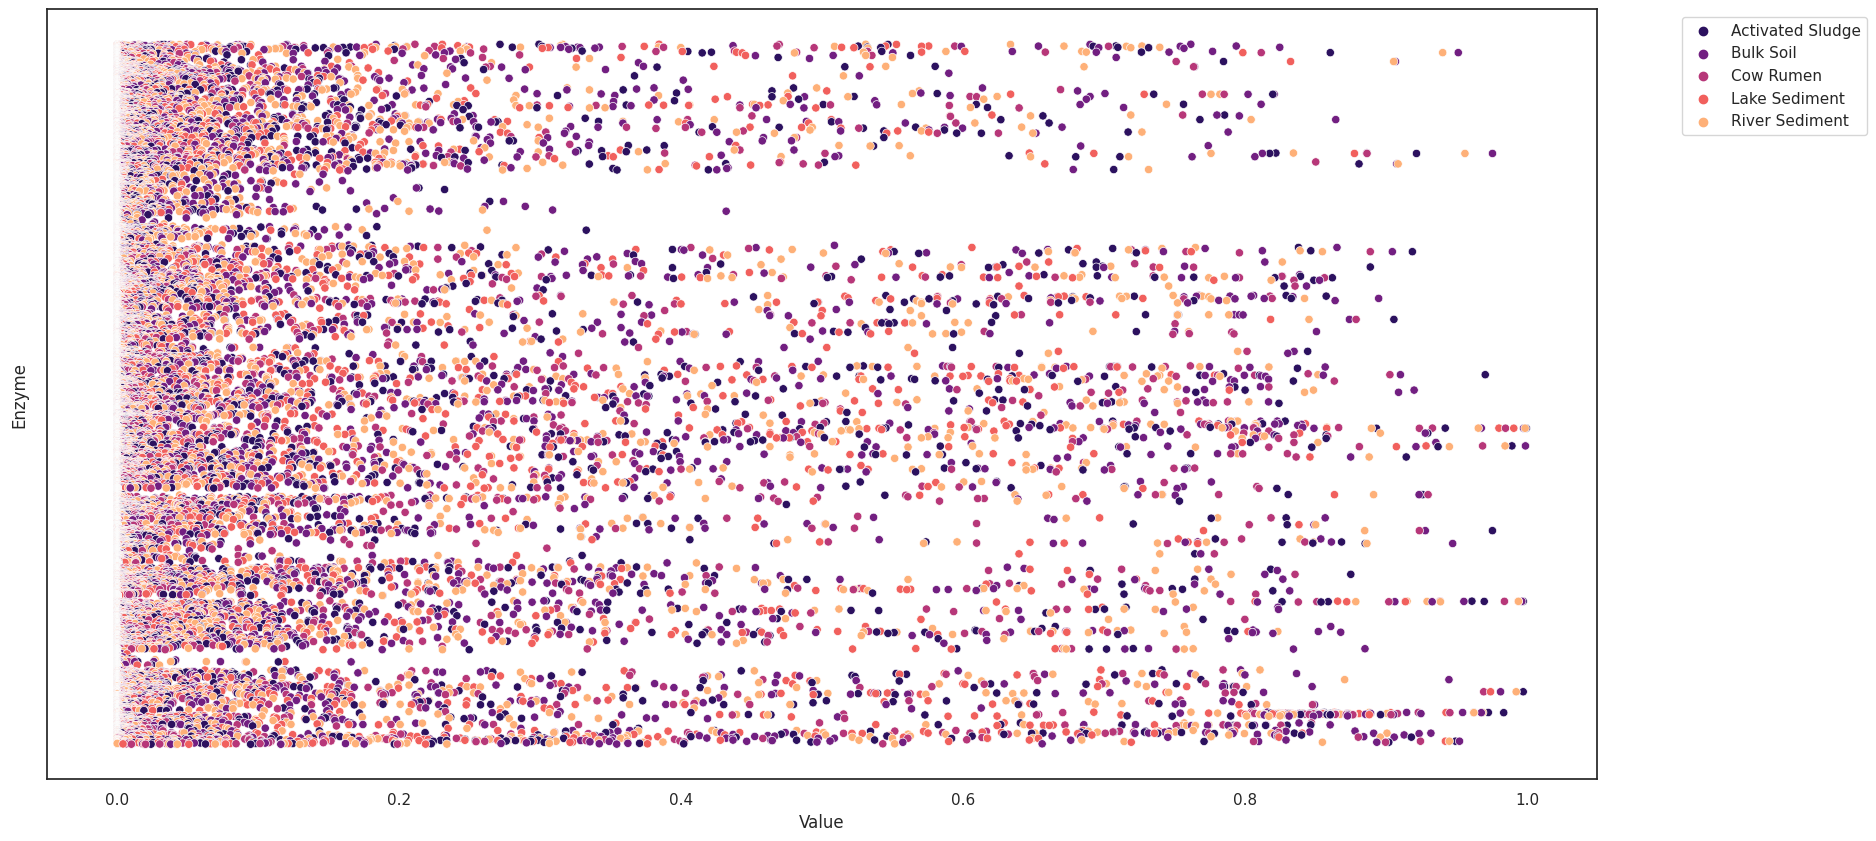

In [11]:
sns.set_context(context = 'paper')
sns.set_style('white')
sns.set_theme(font='serif')
plt.figure(figsize=(20,10))
melted = clean.reset_index().melt(id_vars='Biome', var_name='Enzyme', value_name='Value')
melted
sns.set_style('white')
sns.scatterplot(data = melted, x= 'Value', y='Enzyme', hue = 'Biome', palette='magma')
plt.gca().set_yticklabels([])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
